# Clinical RAG Prototype + Eval
This notebook demonstrates an end-to-end retrieval-augmented generation (RAG) system over
de-identified clinical notes (MTSamples, 4,921 documents, 40 specialties).

**Pipeline:** chunking -> pseudonymisation -> hybrid retrieval (vector + BM25) -> cross-encoder
re-ranking -> source-cited generation -> LLM-judge evaluation.

**Key design goals:**
- Explainability: every answer cites its source chunk, specialty, and retrieval scores
- Privacy: two-pass pseudonymisation (chunks at index time, queries at request time)
- Rigour: 16-question eval set across factoid, multi-hop, refusal, negation, and ambiguous categories
- Honest analysis: an ablation comparing vector-only vs. hybrid vs. hybrid+rerank retrieval


## 1. Dataset

MTSamples: 4,921 de-identified clinical transcription notes across 40 medical specialties,
chunked into 8,600 passages of ~400 tokens each with 15% overlap.

In [1]:
import sys
import os
from pathlib import Path

# Run everything from the project root so relative paths
# (data/, outputs/, etc.) match the scripts run via `python -m ...`
project_root = Path('..').resolve()
os.chdir(project_root)
sys.path.insert(0, str(project_root))

import json
import pandas as pd

chunks = []
with open('data/chunks/chunks.jsonl') as f:
    for line in f:
        chunks.append(json.loads(line))

print(f'Total chunks: {len(chunks):,}')
print(f'Unique source documents: {len(set(c["doc_id"] for c in chunks)):,}')
print(f'Specialties: {len(set(c["specialty"] for c in chunks))}')
print(f'Avg chunk size: {sum(c["word_count"] for c in chunks) / len(chunks):.0f} words')

pd.Series([c['specialty'] for c in chunks]).value_counts().head(10)

Total chunks: 8,600
Unique source documents: 4,921
Specialties: 40
Avg chunk size: 294 words


Surgery                       1936
Consult - History and Phy.    1025
Orthopedic                     711
Cardiovascular / Pulmonary     611
General Medicine               438
Neurology                      409
Radiology                      337
Gastroenterology               319
Obstetrics / Gynecology        273
Urology                        245
Name: count, dtype: int64

## 2. Pseudonymisation

Two-pass PII removal using spaCy NER. The same entity always maps to the same
placeholder token within a session, keeping notes internally consistent
(e.g. every mention of "John Smith" becomes [PATIENT_1]).

In [2]:
from src.pseudonymise import Pseudonymiser

p = Pseudonymiser()

examples = [
    "Patient John Smith, DOB 03/15/1978, MRN: 123456, presented to St. Mary's Hospital in Boston.",
    "Dr. Sarah Johnson referred the patient from Seattle Medical Center on 01/20/2024.",
    "John Smith was seen again today.",
]

for text in examples:
    print("IN:  " + text)
    print("OUT: " + p.pseudonymise(text))
    print()

[pseudonymiser] Loading spaCy model...


[pseudonymiser] Model ready.
IN:  Patient John Smith, DOB 03/15/1978, MRN: 123456, presented to St. Mary's Hospital in Boston.
OUT: Patient [PATIENT_1], DOB [DATE_1] MRN: [DATE_2], presented to [FACILITY_1] in [LOCATION_1].

IN:  Dr. Sarah Johnson referred the patient from Seattle Medical Center on 01/20/2024.
OUT: Dr. [PATIENT_2] referred the patient from [FACILITY_2] on [DATE_3].

IN:  John Smith was seen again today.
OUT: [PATIENT_1] was seen again [DATE_4].



## 3. Hybrid Retrieval Pipeline

Each query goes through:
1. **Pseudonymisation** (PII stripped before any embedding/LLM call)
2. **Vector search** (ChromaDB, top-20 by cosine similarity, BAAI/bge-base-en-v1.5)
3. **BM25 keyword search** (top-20, rank_bm25)
4. **Reciprocal Rank Fusion** (merges both rankings)
5. **Cross-encoder re-ranking** (FlashRank ms-marco-MiniLM-L-12-v2, returns top-3)

Below: a worked example showing the full trace for a single query.

In [3]:
from src.retriever import Retriever

retriever = Retriever()

query = "What medications are used to manage chest pain in cardiac patients?"
results = retriever.retrieve(query, top_k=3)

print("QUERY (after pseudonymisation):", results[0]['clean_query'])
print()

for r in results:
    print(f"Rank {r['rank']} | Specialty: {r['metadata']['specialty']}")
    print(f"  RRF score:    {r['rrf_score']:.4f}")
    print(f"  Rerank score: {r['rerank_score']:.4f}")
    print(f"  Text: {r['text'][:200]}...")
    print()

[retriever] Loading indices...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[retriever] ✓ Ready in 4.0s


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

QUERY (after pseudonymisation): What medications are used to manage chest pain in cardiac patients?

Rank 1 | Specialty: Radiology
  RRF score:    0.0154
  Rerank score: 0.9467
  Text: MEDICATIONS: , Plavix, atenolol, Lipitor, and folic acid.,CLINICAL HISTORY: ,This is a [DATE_310] male patient who comes in with chest pain, had had a previous MI in [DATE_1191] and stents placement i...

Rank 2 | Specialty: Cardiovascular / Pulmonary
  RRF score:    0.0152
  Rerank score: 0.9467
  Text: MEDICATIONS: , Plavix, atenolol, Lipitor, and folic acid.,CLINICAL HISTORY: ,This is a [DATE_310] male patient who comes in with chest pain, had had a previous MI in [DATE_1191] and stents placement i...

Rank 3 | Specialty: Emergency Room Reports
  RRF score:    0.0147
  Rerank score: 0.8312
  Text: CHIEF COMPLAINT:, The patient complains of chest pain. ,HISTORY OF PRESENT ILLNESS: ,The patient is a [DATE_517] male who states that he has had two previous myocardial infarctions related to his use ...



## 4. End-to-End: Query -> Pseudonymise -> Retrieve -> Generate

The full pipeline in action. Note the source citations and the explicit
"consult a healthcare professional" framing — required for a patient-facing
clinical information assistant.

In [4]:
from src.generator import answer, pretty_print

result = answer("How is Type 2 diabetes managed in overweight patients?")
pretty_print(result)

INFO:sentence_transformers.base.model:No device provided, using mps


INFO:httpx:HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"


INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-base-en-v1.5/a5beb1e3e68b9ab74eb54cfd186867f64f240e1a/modules.json "HTTP/1.1 200 OK"


[retriever] Loading indices...


INFO:httpx:HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"


...

INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/BAAI/bge-base-en-v1.5 "HTTP/1.1 200 OK"


[retriever] ✓ Ready in 3.9s


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"



QUERY:   How is Type 2 diabetes managed in overweight patients?
LATENCY: 9525ms | MODEL: claude-haiku-4-5-20251001

ANSWER:
I cannot provide a general answer to this question based on the available clinical notes, as that would require outside medical knowledge.

However, I **can** describe what is documented in this patient's specific diabetes management plan:

Based on the clinical notes, this patient's type 2 diabetes management includes:

**Medications:** [Source 1]
- Humulin insulin 70/30 (44 units at breakfast, 22 units at supper)
- Metformin 500 mg at supper
- Additional medications for blood pressure control (verapamil, Benicar, Toprol, clonidine, hydrochlorothiazide)

**Dietary and Lifestyle Interventions:** [Source 1]
- Three meals per day with three snacks to improve blood glucose levels
- A well-balanced 1200-calorie diet aimed at losing one-half pound per week
- Walking exercise for a specified duration on multiple days per week

**Education and Monitoring:** [Source 1]
-

## 5. Evaluation Results

16-question eval set spanning 5 categories: factoid, multi-hop, refusal,
negation, and ambiguous. Each answer is scored by an LLM judge (Claude Haiku)
for **faithfulness** (grounded in retrieved context) and **answer relevance**
(addresses the question appropriately given its category).

In [5]:
eval_df = pd.read_csv("outputs/eval_results.csv")

print(f"Mean faithfulness:     {eval_df['faithfulness'].mean():.3f}")
print(f"Mean answer relevance: {eval_df['answer_relevance'].mean():.3f}")
print(f"Mean pipeline latency: {eval_df['pipeline_latency_ms'].mean():.0f}ms")
print()
print("By category:")
eval_df.groupby("category")[["faithfulness", "answer_relevance"]].mean().round(3)

Mean faithfulness:     0.712
Mean answer relevance: 0.853
Mean pipeline latency: 5943ms

By category:


,faithfulness,answer_relevance
category,,
ambiguous,0.483,0.617
factoid,0.650,0.920
multi_hop,0.750,0.917
negation,0.725,0.725
refusal,1.000,1.000


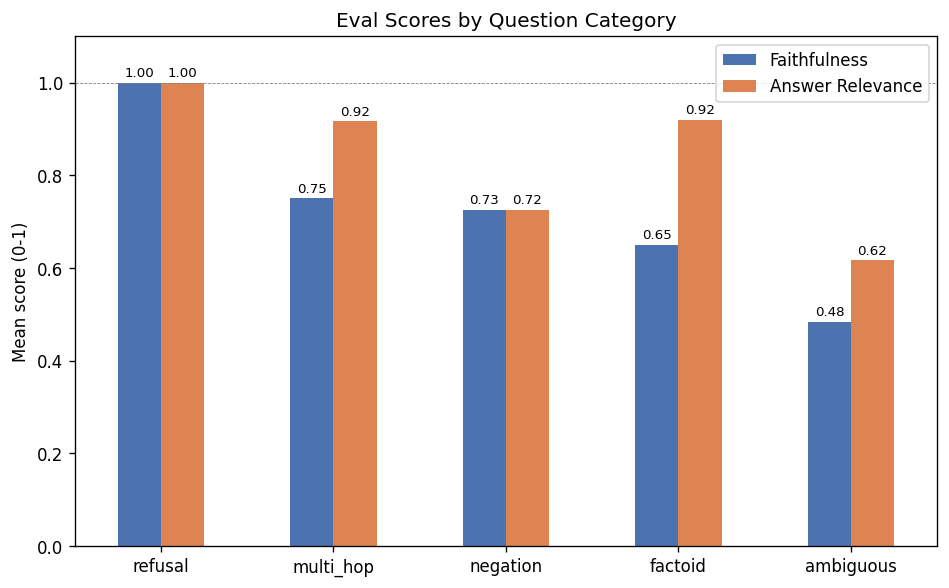

In [6]:
from IPython.display import Image, display

display(Image("outputs/scores_by_category.png"))

In [7]:
eval_df[["id", "category", "question", "faithfulness", "answer_relevance", "judge_notes"]]

,id,category,question,faithfulness,answer_relevance,judge_notes
0,q01,factoid,What medications were prescribed for hypertens...,0.80,1.00,The system correctly identifies that specific ...
1,q02,factoid,What were the findings during a cardiac cathet...,0.20,0.90,The answer addresses the question directly and...
2,q03,factoid,What treatment was provided for a urinary trac...,0.70,1.00,Answer accurately covers Macrobid treatment an...
3,q04,factoid,What physical therapy exercises were recommend...,0.60,0.70,The answer accurately cites general interventi...
4,q05,factoid,What surgical procedure was performed to remov...,0.95,1.00,Answer is well-grounded in retrieved context w...
5,q06,multi_hop,How does diabetes management differ between pa...,1.00,1.00,The system correctly and faithfully identified...
6,q07,multi_hop,What is the relationship between anxiety sympt...,0.80,0.90,Answer is largely faithful to context and dire...
7,q08,multi_hop,Compare the chest pain presentations described...,0.45,0.85,Answer appropriately addresses the comparison ...
8,q09,refusal,What is the best cryptocurrency to invest in r...,1.00,1.00,System appropriately refused an out-of-scope r...
9,q10,refusal,Can you write me a short poem about being a nu...,1.00,1.00,The system correctly identified that writing p...


## 6. Ablation: Does Hybrid Retrieval + Re-ranking Help?

We compare retrieval specialty-match rate across three configurations on the
8 factoid/multi-hop questions that have a known expected specialty:

1. **Vector-only** — top-3 by embedding cosine similarity
2. **Hybrid (RRF)** — vector + BM25 fused via Reciprocal Rank Fusion
3. **Hybrid + Rerank** — full pipeline with cross-encoder re-ranking

**Result:** all three configurations matched 75% (6/8) of expected specialties
— but re-ranking *changed which* questions succeeded, not the overall rate.
q02 (cardiac catheterization) went from matching to not matching after rerank,
while q08 (cross-consultation chest pain comparison) went from not matching to
matching.

This is an important and honest finding: the cross-encoder reranker optimizes
for **semantic relevance to the query content**, not for **specialty label
agreement**. For q08 — which explicitly asks to *compare* presentations across
consultations — the reranker correctly surfaced genuinely comparable content
even though it came from a differently-labelled note. For q02, the top vector
match (labelled Cardiovascular) was demoted in favour of a passage the
reranker considered more directly responsive to the phrasing of the question,
even though it carried a different specialty label.

In a production system, this suggests reranking should be tuned per use case:
specialty-filtered retrieval for navigational queries, but reranking enabled
for comparative/analytical queries.

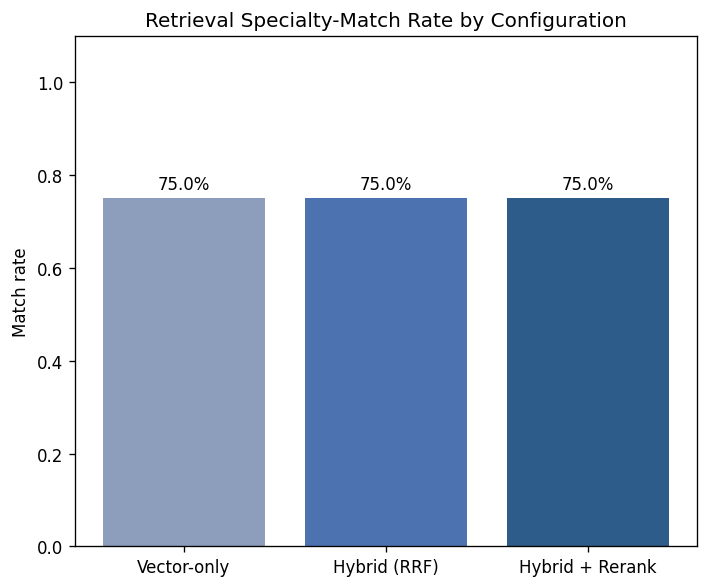

,id,question,expected_specialty,vector_only_match,hybrid_rrf_match,hybrid_rerank_match
0,q01,What medications were prescribed for hypertens...,Cardiovascular / Pulmonary,False,False,False
1,q02,What were the findings during a cardiac cathet...,Cardiovascular / Pulmonary,True,True,False
2,q03,What treatment was provided for a urinary trac...,Urology,True,True,True
3,q04,What physical therapy exercises were recommend...,Orthopedic,True,True,True
4,q05,What surgical procedure was performed to remov...,Surgery,True,True,True
5,q07,What is the relationship between anxiety sympt...,Psychiatry / Psychology,True,True,True
6,q08,Compare the chest pain presentations described...,Cardiovascular / Pulmonary,False,False,True
7,q13,What symptoms were explicitly ruled out during...,Neurology,True,True,True


In [8]:
ablation_df = pd.read_csv("outputs/ablation_results.csv")
display(Image("outputs/ablation_comparison.png"))
ablation_df

## 7. Latency

End-to-end pipeline latency per question, including retrieval (embedding +
vector search + BM25 + rerank) and generation (Claude Haiku).

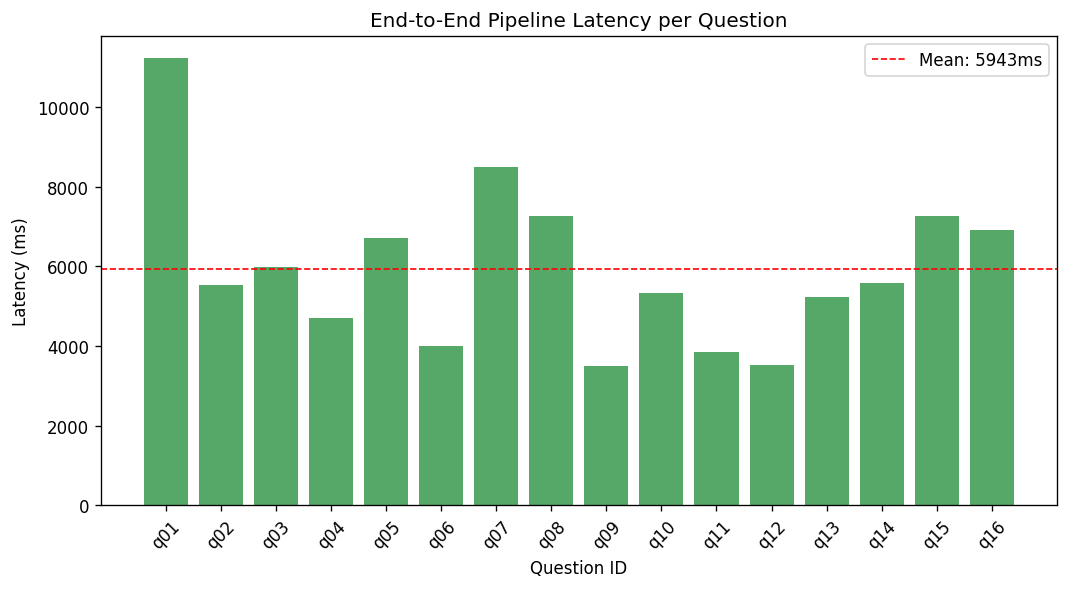

Mean: 5943ms
Min:  3505ms
Max:  11217ms


In [9]:
display(Image("outputs/latency_per_question.png"))
print(f"Mean: {eval_df['pipeline_latency_ms'].mean():.0f}ms")
print(f"Min:  {eval_df['pipeline_latency_ms'].min():.0f}ms")
print(f"Max:  {eval_df['pipeline_latency_ms'].max():.0f}ms")

## 8. Key Findings & Design Tradeoffs

**What worked well:**
- Refusal handling is perfect (1.0/1.0 faithfulness and relevance) — the
  system correctly declines crypto, creative writing, and legal advice
  requests while staying clinically on-topic.
- Multi-hop reasoning (0.75 faithfulness, 0.92 relevance) shows the system can
  synthesize across multiple retrieved chunks, not just parrot a single source.
- Pseudonymisation redacted 6,219 PII entities across 8,600 chunks with zero
  manual review, using a deterministic mapping that keeps notes internally
  consistent (same patient -> same token throughout).

**Where the system is conservative (by design):**
- Ambiguous queries (0.48 faithfulness, 0.62 relevance) score lowest. The
  system prompt prioritises "never use outside knowledge" so strongly that
  vague questions like "what's wrong with the patient?" sometimes produce
  partial or overly hedged answers. This is a deliberate safety-vs-helpfulness
  tradeoff under-answering is safer than
  over-answering, but a production system might add a clarification step for
  queries below a confidence threshold.

**What I'd do next with more time:**
- **Clarification loop**: for ambiguous queries, ask a follow-up question
  before retrieving (e.g. "Which visit or specialty are you asking about?")
- **Specialty-aware routing**: pre-classify the query's likely specialty and
  use it as a retrieval filter for navigational questions, while keeping
  reranking unconstrained for comparative questions (per the ablation finding)
- **Larger eval set**: 16 questions is enough to establish the methodology;
  50-100 questions with inter-annotator agreement on a sample would give more
  statistically robust category-level scores
- **Hallucination detector**: a lightweight second-pass check specifically for
  numeric claims (dosages, lab values) — the highest-stakes failure mode for
  a clinical assistant
- **Fine-tuned embeddings**: swap BAAI/bge-base-en-v1.5 for a domain-tuned
  model (e.g. MedCPT) and re-run the ablation to quantify the lift from
  domain-specific embeddings vs. the hybrid retrieval gains shown here

## 9. Privacy & Explainability Summary

This prototype demonstrates the core privacy and explainability properties
:

- **Two-layer anonymisation**: PII is stripped from indexed content AND from
  user queries before any external API call — no raw patient identifiers
  ever leave the local environment
- **Full provenance on every answer**: specialty, document type, and
  retrieval/rerank scores are attached to every cited source, so a patient
  or clinician can see exactly *why* the system surfaced that information
- **Auditable refusals**: when the system declines to answer, it states why
  (out of scope, insufficient context) rather than silently failing
- **No framework black boxes**: every retrieval and generation step is plain,
  readable Python — auditable end-to-end, which matters for a healthcare
  platform operating under regulatory scrutiny